# Manufacturing Defect Prediction — Exploratory Data Analysis (EDA)

This analysis evaluates a manufacturing dataset (AI4I 2020) to understand the drivers of machine failure and assess data readiness for machine learning.

### Objectives
- Validate data quality (missing values, duplicates, validity)
- Understand feature distributions and operating regimes
- Identify relationships with the target (Machine failure)
- Derive implications for modeling (features, metrics, preprocessing)

## Import Libraries

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

## Load Dataset

In [59]:
# Load ai42020
df = pd.read_csv('../data/raw/ai4i2020.csv')


### Data Overview and Quality

In [60]:
print("First few rows of the dataframe:\n", df.head())
print("\nDataframe dimensions:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values in each column:\n", df.isnull().sum())
print("\nNumber of duplicate rows:\n", df.duplicated().sum())

First few rows of the dataframe:
    UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0 

### Observations

- Dataset contains 10,000 rows and 14 features  
- No missing values detected  
- Mix of numerical and categorical variables  
- Data structure is consistent and usable  

### Impact

- Dataset is ready for analysis  
- No initial cleaning required  

### Remove Non-Informative Features



In [61]:
# Drop identifier (no predictive value)
df = df.drop(columns=["UDI"])

- The UDI column is an identifier and does not provide predictive information. It is removed to avoid introducing noise into the model.

### Target Variable Analysis

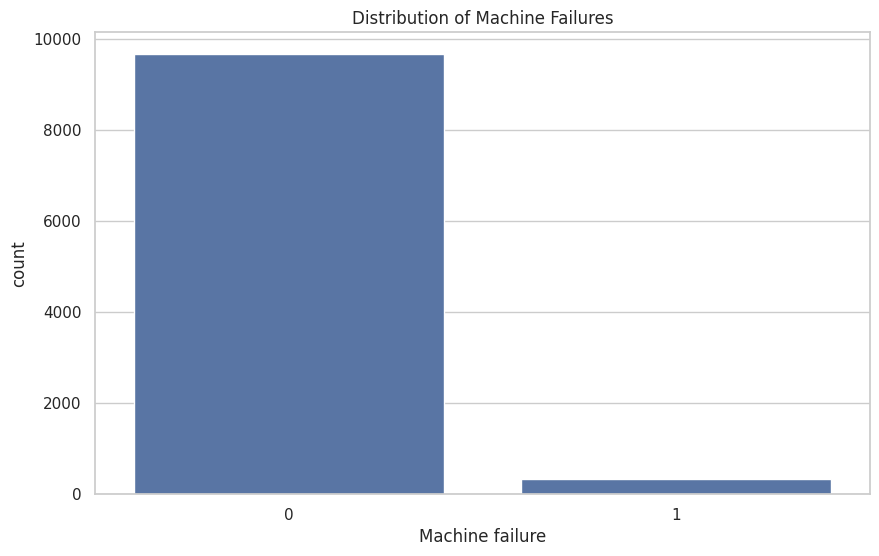

In [62]:
df['Machine failure'].value_counts()
df['Machine failure'].value_counts(normalize=True)

sns.countplot(x='Machine failure', data=df)
plt.title('Distribution of Machine Failures')
plt.show()

### Key Findings

- The dataset is highly imbalanced  
- The majority class corresponds to non-failure cases  

### Impact

Accuracy is not a reliable metric. Evaluation should focus on:
- Recall
- Precision
- F1-score

Class imbalance handling may be required during modeling.

### Statistical Summary

In [63]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.0,108.0,162.0,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.0,0.0,0.0,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.0,0.0,0.0,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.0,0.0,0.0,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.0,0.0,0.0,1.0
OSF,10000.0,0.00980,0.098514,0.0,0.0,0.0,0.0,1.0


### Observations

- Features have different ranges and scales  
- No abnormal values detected  

### Impact

- Feature scaling will be required  
- Data is stable and suitable for modeling  

### Feature Distribution

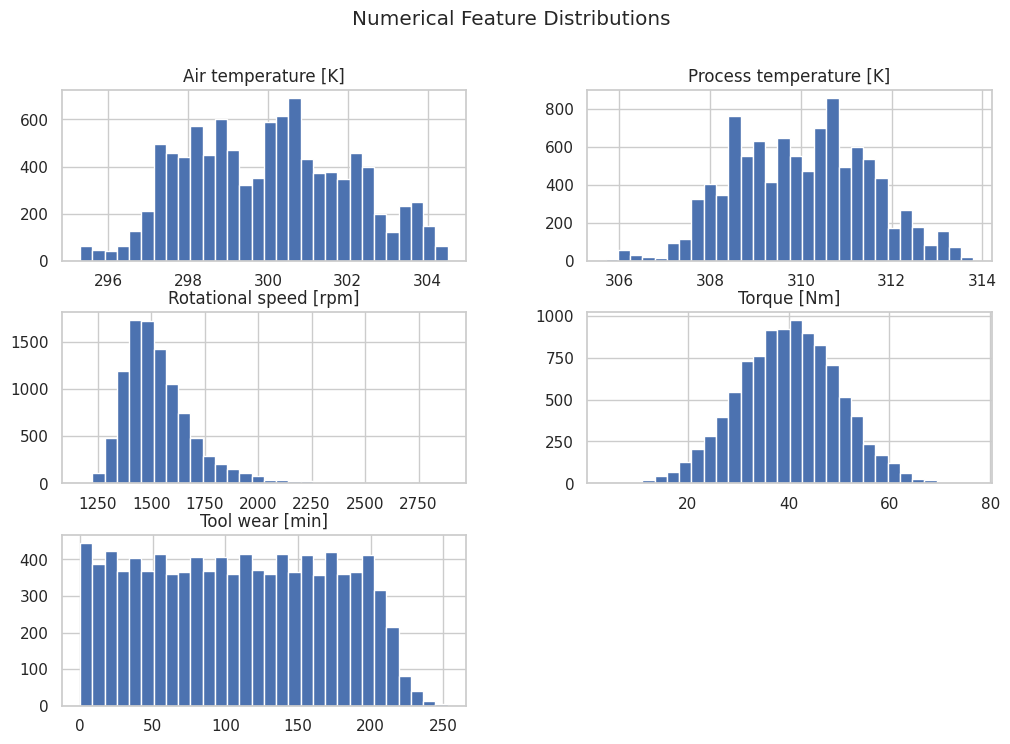

In [64]:
numerical_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

df[numerical_features].hist(bins=30, figsize=(12,8))
plt.suptitle("Numerical Feature Distributions")
plt.show()

### Key Insights

- Air temperature, Process temperature, and Torque show approximately normal distributions, indicating stable operating conditions.
- Rotational speed is concentrated within a limited range, suggesting controlled machine operation.
- Tool wear is more evenly distributed, capturing different stages of component degradation.

### Impact

- No transformation is required for most features  
- Data appears stable and suitable for modeling  

### Categorical Feature

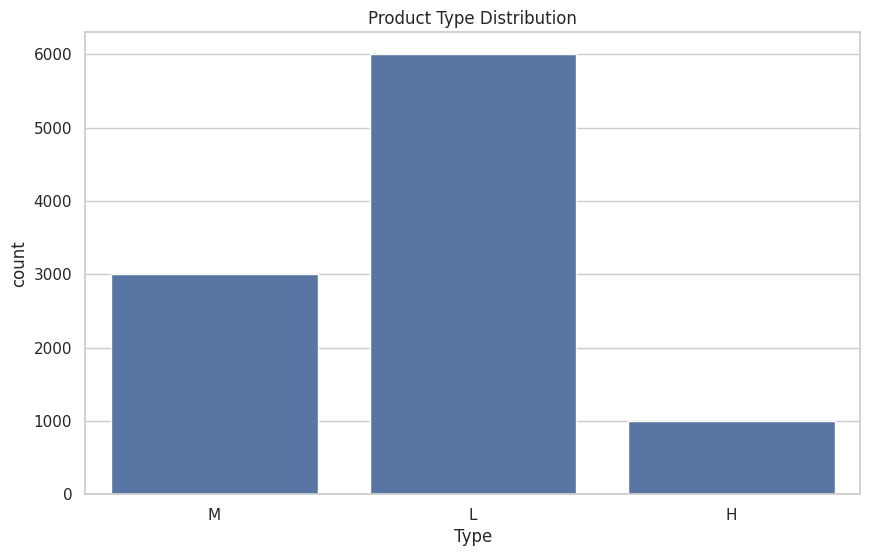

In [65]:
sns.countplot(data=df, x="Type")
plt.title("Product Type Distribution")
plt.show()

- Product type (L, M, H) represents different operational categories and may influence failure behavior. It should be included in modeling after encoding.

### Data Leakage Analysis

In [66]:
leakage_features = ["TWF", "HDF", "PWF", "OSF", "RNF"]

df[leakage_features].sum()

TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64

### Data Leakage Analysis

Failure-type variables (TWF, HDF, PWF, OSF, RNF) represent specific failure modes.

These variables are not independent predictors but direct indicators of machine failure.

Including them in the model would introduce data leakage, as they encode the target outcome.

### Decision

These features must be removed before modeling.

### Remove Leakage

In [67]:
df = df.drop(columns=["TWF", "HDF", "PWF", "OSF", "RNF"])

### Correlation Analysis

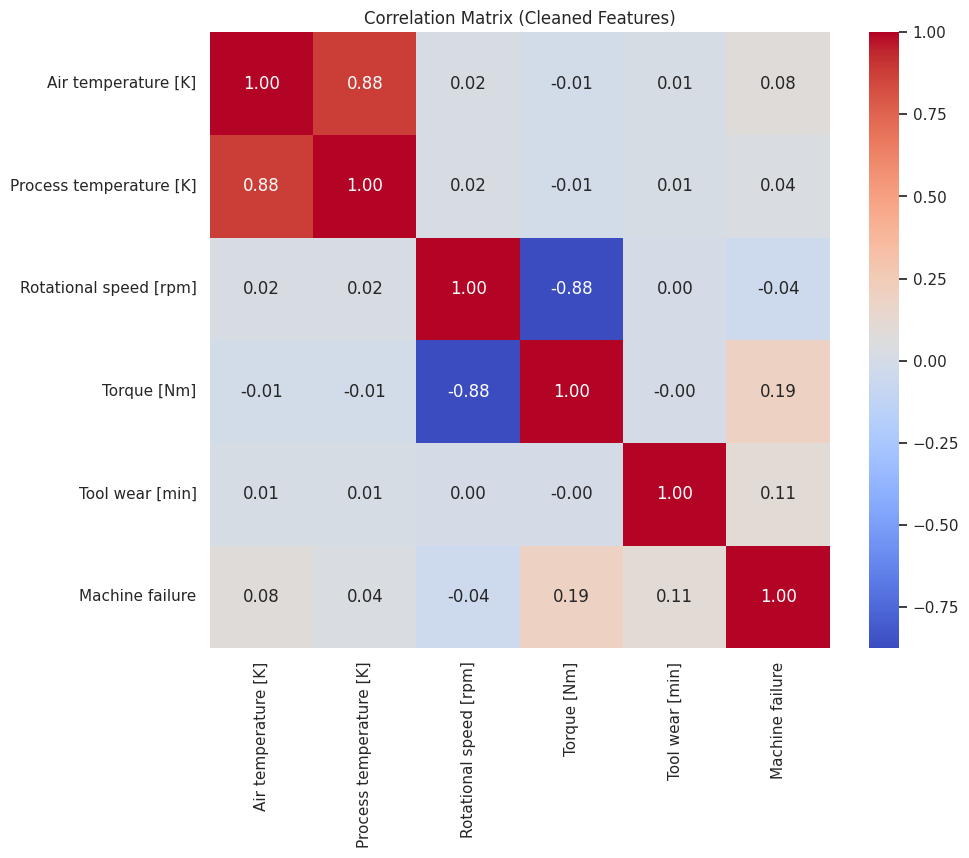

In [68]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (Cleaned Features)")
plt.show()

### Key Insights

- Strong positive correlation:
  - Air temperature ↔ Process temperature (~0.88)

- Strong negative correlation:
  - Rotational speed ↔ Torque (~ -0.88)

These relationships reflect expected physical behavior and are not problematic.

- Weak to moderate correlation with target:
  - Torque (~0.19)
  - Tool wear (~0.11)

### Impact

- No single feature strongly predicts failure  
- The problem requires a model to capture interactions between variables  
- Although some features show moderate correlation with the target, no single variable strongly explains machine failure.
- This indicates that failure is likely driven by a combination of factors rather than a single condition.
- Therefore, machine learning models are required to capture interactions between variables.

### Feature vs Target

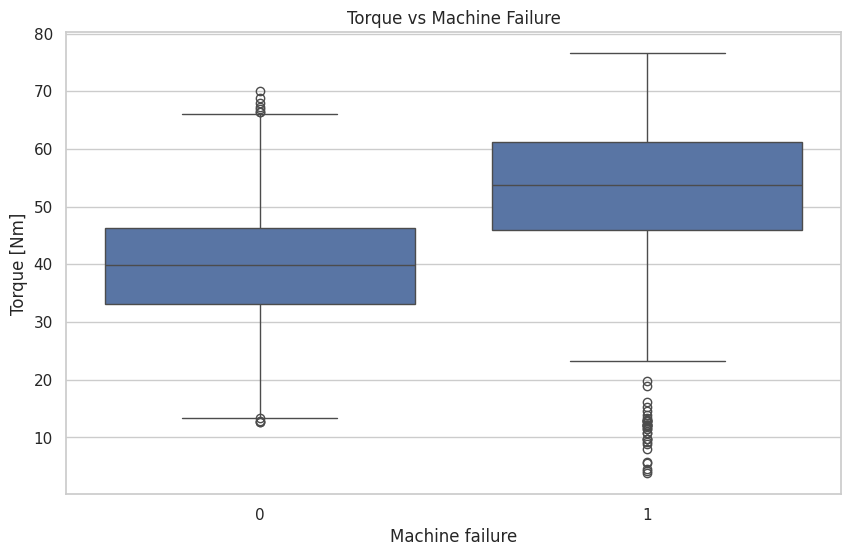

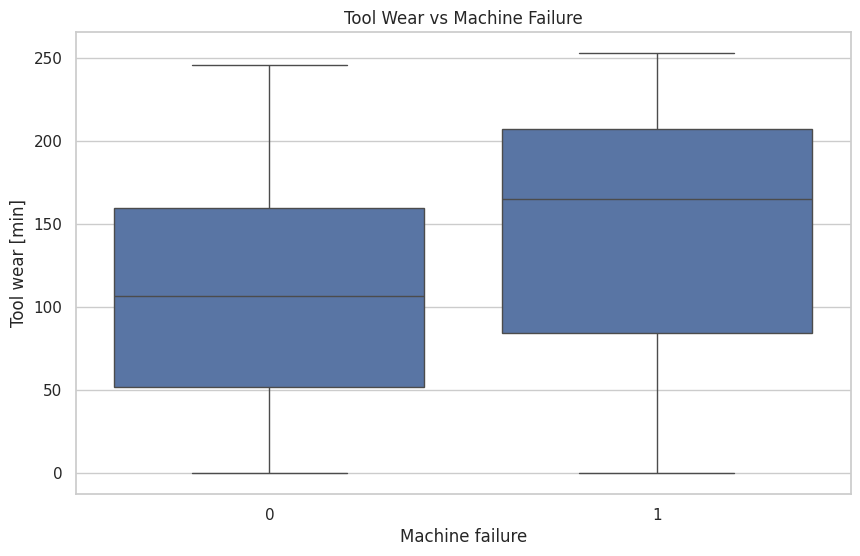

In [69]:
sns.boxplot(x="Machine failure", y="Torque [Nm]", data=df)
plt.title("Torque vs Machine Failure")
plt.show()

sns.boxplot(x="Machine failure", y="Tool wear [min]", data=df)
plt.title("Tool Wear vs Machine Failure")
plt.show()

### Insights

- Failure cases tend to occur at higher torque levels  
- Tool wear is slightly higher in failure cases  

### Impact

Torque and Tool wear are important predictive signals.

### Outliers Analysis

In [70]:
def count_outliers(col):
    Q1 = col.quantile(0.25)
    Q3 = col.quantile(0.75)
    IQR = Q3 - Q1
    return ((col < Q1 - 1.5 * IQR) | (col > Q3 + 1.5 * IQR)).sum()

numeric_df.apply(count_outliers)

Air temperature [K]          0
Process temperature [K]      0
Rotational speed [rpm]     418
Torque [Nm]                 69
Tool wear [min]              0
Machine failure            339
dtype: int64

### Outlier Analysis

Outliers were detected using the IQR method across numerical features.

However, no removal is performed because:

- The dataset represents realistic operating conditions  
- Extreme values remain physically plausible  
- Statistical methods like IQR may incorrectly flag valid observations  

### Decision

All observations are retained to preserve important patterns in failure behavior.

## Final EDA Summary

- The dataset is clean with no missing values or duplicates  
- UDI was removed as a non-informative identifier  
- Failure-type variables were removed to prevent data leakage  
- The target variable is highly imbalanced  
- No single feature strongly predicts failure  
- Key predictive signals include:
  - Torque  
  - Tool wear  
  - Rotational speed  
- Outliers were detected but retained due to their physical plausibility  

## Next Steps

- Encode categorical variables (Type)  
- Apply feature scaling  
- Split data into training and testing sets  
- Train baseline models:
  - Logistic Regression  
  - Random Forest  
  - XGBoost  
- Handle class imbalance using:
  - class_weight  
  - SMOTE (if needed)  
- Evaluate using Recall and F1-score  